In [5]:
import kagglehub

kagglehub.dataset_download("ademboukhris/cars-body-type-cropped")

'/kaggle/input/cars-body-type-cropped'

In [2]:
!pip3 install tensorflow

In [1]:
import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/cars-body-type-cropped/Cars_Body_Type/train',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    '/kaggle/input/cars-body-type-cropped/Cars_Body_Type/valid',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    '/kaggle/input/cars-body-type-cropped/Cars_Body_Type/test',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Class names:", class_names)

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/input/cars-body-type-cropped/Cars_Body_Type/train'

In [21]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, GlobalAveragePooling2D)

base_model = EfficientNetB0(include_top=False, weights='imagenet',
                            input_shape=image_size + (3, ))
base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,442 (16.08 MB)

 Trainable params: 4,172,419 (15.92 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [22]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('my_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]


In [24]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.4171 - loss: 1.4670
Epoch 1: val_accuracy improved from -inf to 0.20902, saving model to my_model.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 230s 947ms/step - accuracy: 0.4179 - loss: 1.4652 - val_accuracy: 0.2090 - val_loss: 2.7733 - learning_rate: 0.0010
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.7352 - loss: 0.7183
Epoch 2: val_accuracy did not improve from 0.20902
168/168 ━━━━━━━━━━━━━━━━━━━━ 124s 674ms/step - accuracy: 0.7352 - loss: 0.7181 - val_accuracy: 0.1160 - val_loss: 4.3277 - learning_rate: 0.0010
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8109 - loss: 0.5266
Epoch 3: val_accuracy did not improve from 0.20902
168/168 ━━━━━━━━━━━━━━━━━━━━ 114s 677ms/step - accuracy: 0.8109 - loss: 0.5266 - val_accuracy: 0.1160 - val_loss: 3.3768 - learning_rate: 0.0010
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.8371 - loss: 0.4631
Epoch 4: val_accuracy did n

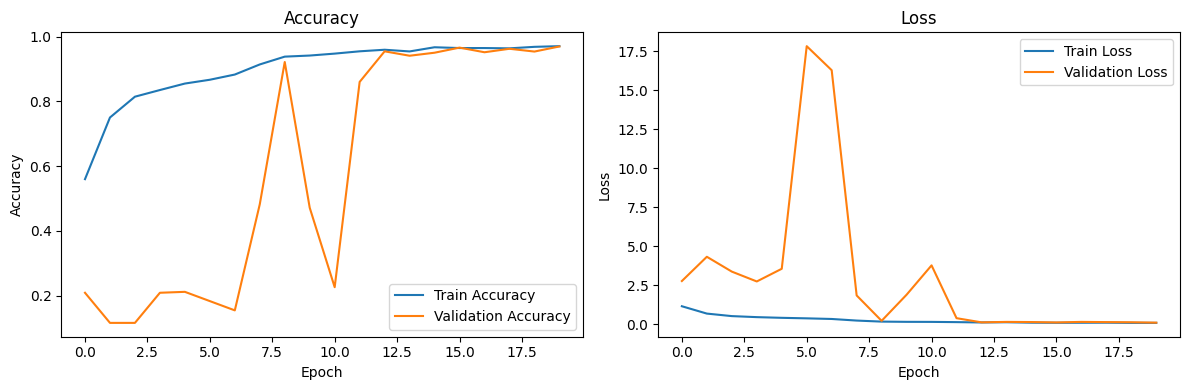

26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 393ms/step - accuracy: 0.9680 - loss: 0.0861
Test accuracy: 0.9663
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 462ms/step
              precision    recall  f1-score   support

 Convertible       0.98      0.97      0.97       174
       Coupe       0.95      0.95      0.95        79
   Hatchback       0.92      0.94      0.93        99
     Pick-Up       0.97      0.99      0.98       110
         SUV       0.98      0.96      0.97       125
       Sedan       0.98      0.95      0.97       109
         VAN       0.97      0.99      0.98       106

    accuracy                           0.97       802
   macro avg       0.96      0.97      0.96       802
weighted avg       0.97      0.97      0.97       802



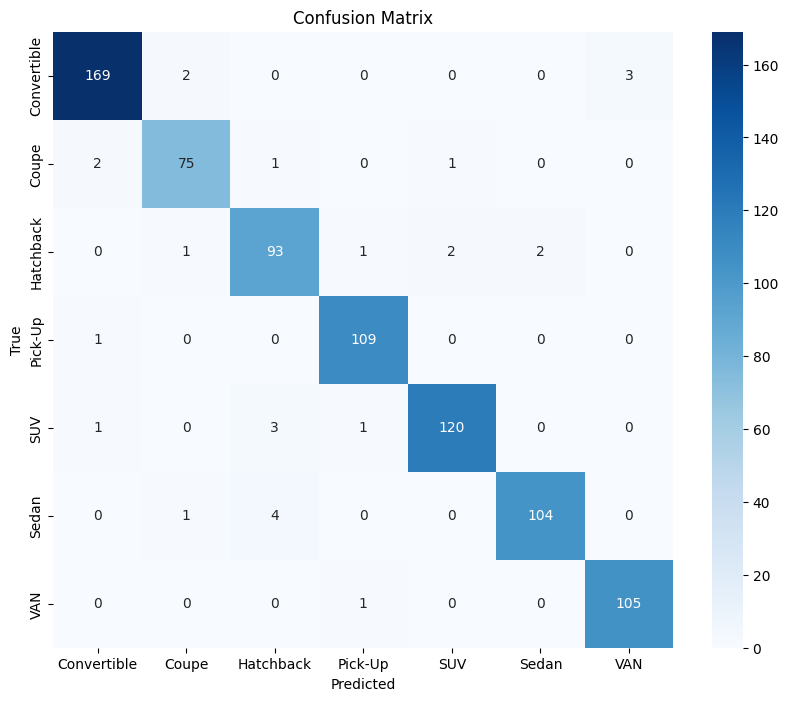

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [33]:
import tensorflow as tf

model.save('car_body_type_classifier.keras')

def predict_car_type(image_path, model, class_names):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    img_array /= 255.0

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    print(
        "This image most likely belongs to {} with a {:.2f}% confidence."
        .format(class_names[np.argmax(score)], 100 * np.max(score))
    )

    return class_names[np.argmax(score)], 100 * np.max(score)

In [34]:
predicted_class, confidence = predict_car_type('VAN.jpg', model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
This image most likely belongs to VAN with a 31.18% confidence.
